# Network metrics basics

Building and analysing graphs with NetworkX: a Marvel character interaction network (JSON) and a retweet network from the 2019 Spanish general election (#28A). Covers graph construction, density, weighted degree, degree distributions, centrality measures, group-level aggregation, GEXF export for Gephi, and Erdős–Rényi random graph models.

*Narrative translated to English from the original Spanish; printed outputs and figure labels are shown as originally executed (in Spanish).*

## Part 1: Marvel character interaction network

In [1]:
# Imports

%matplotlib inline
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Path to the JSON file
file_path = '/content/drive/MyDrive/Def_PEC1_enunciado/data/MarvelInteractions.json'

# We load the JSON file
with open(file_path, 'r') as file:
    data = json.load(file)

print(data)

In [3]:
# We create an undirected graph
G = nx.Graph()

# We add nodes
for node in data['nodes']:
    G.add_node(node['name'], group=node['group'], comicCount=node['comicCount'])

# We add links
for link in data['links']:
    # Get the character names of the nodes
    source_name = data['nodes'][link['source']]['name']
    target_name = data['nodes'][link['target']]['name']

    # We add the link with the weight
    G.add_edge(source_name, target_name, weight=link['value'])


In [4]:
# We compute several properties of the graph
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

# We compute the diameter of the graph, which requires the graph to be connected.
# If the graph is not connected, we compute the diameter of the largest connected component
if nx.is_connected(G):
    diameter = nx.diameter(G)
else:
    largest_cc = max(nx.connected_components(G), key=len)
    subgraph = G.subgraph(largest_cc)
    diameter = nx.diameter(subgraph)

#Check for isolated nodes
isolated_nodes = list(nx.isolates(G))
has_isolated_nodes = len(isolated_nodes) > 0

num_nodes, num_edges, density, diameter, has_isolated_nodes, isolated_nodes




(50, 1151, 0.9395918367346939, 2, False, [])

Number of nodes: The graph contains 50 nodes. Each node represents a character from the Marvel universe.

Number of edges: There are 1151 edges in the graph. These edges represent interactions or relationships between the characters.

Graph density: The density of the graph is approximately 0.940. This is a high density, which indicates that a large number of the possible pairs of nodes are connected by an edge.

Graph diameter: The diameter of the graph is 2. This means that the greatest distance between any pair of nodes in the graph is two edges. This small diameter suggests a highly interconnected network.

Isolated nodes: There are no isolated nodes in the graph. This means that every character is connected to at least one other character.


Analysis of the graph's morphology
High density: The high density of the graph indicates a tightly knit network in which the characters have many connections with one another. This is typical of a universe like Marvel's, where characters interact and collaborate frequently.

Small diameter: The small diameter suggests that the Marvel universe is a "small world", where any two characters can be connected through a short path of relationships. This reflects the interconnected storylines and the frequent crossovers of Marvel comics.

Absence of isolated nodes: The absence of isolated nodes implies that all the characters included in this dataset are part of a wider network of relationships, which highlights the collaborative nature of the Marvel universe.


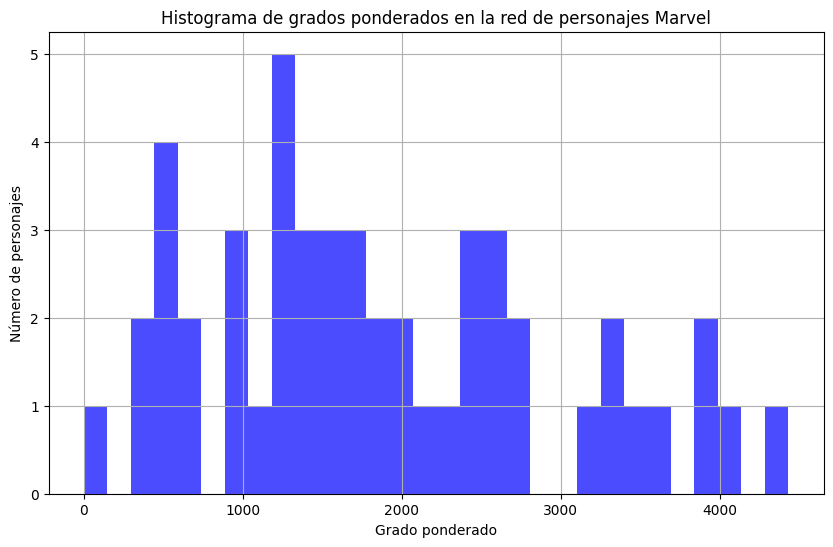

('Iron Man', 4430, 'Spider-Man (Ultimate)', 2, 1882.56, 1659.0)

In [5]:
# We compute the weighted degree of each node
weighted_degrees = {node: sum(weight for _, _, weight in G.edges(node, data='weight')) for node in G.nodes}

# We find the node with the maximum and minimum weighted degree
max_degree_node = max(weighted_degrees, key=weighted_degrees.get)
min_degree_node = min(weighted_degrees, key=weighted_degrees.get)
max_degree = weighted_degrees[max_degree_node]
min_degree = weighted_degrees[min_degree_node]

# We compute the mean and the median of the weighted degrees
mean_degree = np.mean(list(weighted_degrees.values()))
median_degree = np.median(list(weighted_degrees.values()))

# Preparing the data for the histogram
degrees = list(weighted_degrees.values())

# We plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=30, color='blue', alpha=0.7)
plt.title('Histograma de grados ponderados en la red de personajes Marvel')
plt.xlabel('Grado ponderado')
plt.ylabel('Número de personajes')
plt.grid(True)
plt.show()

max_degree_node, max_degree, min_degree_node, min_degree, mean_degree, median_degree



Maximum weighted degree: The character "Iron Man" has the maximum weighted degree of 4430. This indicates that Iron Man has the greatest total interaction weight with other characters.

Minimum weighted degree: The character "Spider-Man (Ultimate)" has the lowest weighted degree of 2, which suggests very limited interactions in the context of this dataset.

Mean of the weighted degrees: The mean of the weighted degrees in the graph is approximately 1882.56.

Median of the weighted degrees: The median of the weighted degrees is 1659.0.


From the histogram representing the distribution of these weighted degrees:

The histogram shows a right-skewed distribution, which indicates that a large number of characters have lower interaction weights, while a few characters have significantly higher interaction weights.

The presence of characters with very high weighted degrees, such as Iron Man, suggests that there are central or key characters in the Marvel universe with extensive connections.

The skew toward the lower end suggests that, although there are some very influential characters, most of them have fewer interactions, which reveals the existence of a few central characters in a vast network of other, less connected ones.


In [6]:


# We create a new graph for the superhero groups
group_graph = nx.Graph()

# We initialize the node attributes for the group graph
group_appearances = defaultdict(int)

# Aggregating comic appearances for each group
for node in data['nodes']:
    group = node['group']
    comic_count = node['comicCount']
    group_appearances[group] += comic_count
    if group not in group_graph:
        group_graph.add_node(group, comicCount=group_appearances[group])


group_edge_weights = defaultdict(int)

# Aggregating weights for edges between groups
for link in data['links']:
    source_group = data['nodes'][link['source']]['group']
    target_group = data['nodes'][link['target']]['group']
    weight = link['value']

    # We avoid self-loops in the group graph
    if source_group != target_group:
        group_edge_weights[(source_group, target_group)] += weight

# We add edges to the group graph
for (source_group, target_group), weight in group_edge_weights.items():
    if not group_graph.has_edge(source_group, target_group):
        group_graph.add_edge(source_group, target_group, weight=weight)

# We update the comicCount attribute of each group node
for group in group_graph.nodes:
    group_graph.nodes[group]['comicCount'] = group_appearances[group]

group_graph.nodes(data=True), group_graph.edges(data=True)


(NodeDataView({'Avengers': {'comicCount': 13090}, 'Fantastic Four': {'comicCount': 3512}, 'Defenders': {'comicCount': 1543}, 'X-Men': {'comicCount': 6135}, 'S.W.O.R.D': {'comicCount': 589}, 'X-Force': {'comicCount': 775}, 'None': {'comicCount': 1090}, 'S.H.I.E.L.D': {'comicCount': 302}, "Actors' Equity Association": {'comicCount': 283}, 'Century Clud': {'comicCount': 210}}),
 EdgeDataView([('Avengers', 'Fantastic Four', {'weight': 4958}), ('Avengers', 'Defenders', {'weight': 1790}), ('Avengers', 'X-Men', {'weight': 5357}), ('Avengers', 'S.W.O.R.D', {'weight': 586}), ('Avengers', 'X-Force', {'weight': 313}), ('Avengers', 'None', {'weight': 537}), ('Avengers', 'S.H.I.E.L.D', {'weight': 508}), ('Avengers', "Actors' Equity Association", {'weight': 407}), ('Avengers', 'Century Clud', {'weight': 335}), ('Fantastic Four', 'Defenders', {'weight': 902}), ('Fantastic Four', 'X-Men', {'weight': 2321}), ('Fantastic Four', 'S.W.O.R.D', {'weight': 174}), ('Fantastic Four', 'X-Force', {'weight': 95})

In [7]:
# We recreate the graph with the groups as nodes and their relationships as edges.

# Computing several properties of the group_graph
num_nodes_groups = group_graph.number_of_nodes()
num_edges_groups = group_graph.number_of_edges()
density_groups = nx.density(group_graph)

# We compute the diameter of the group graph
if nx.is_connected(group_graph):
    diameter_groups = nx.diameter(group_graph)
else:
    largest_cc_groups = max(nx.connected_components(group_graph), key=len)
    subgraph_groups = group_graph.subgraph(largest_cc_groups)
    diameter_groups = nx.diameter(subgraph_groups)

# Check for isolated nodes in the group graph
isolated_nodes_groups = list(nx.isolates(group_graph))
has_isolated_nodes_groups = len(isolated_nodes_groups) > 0

num_nodes_groups, num_edges_groups, density_groups, diameter_groups, has_isolated_nodes_groups, isolated_nodes_groups



(10, 44, 0.9777777777777777, 2, False, [])

The analysis of the new graph, which represents the relationships between the superhero groups of the Marvel universe, yields the following results:

Number of nodes: The graph consists of 10 nodes, each of which represents a different superhero group.

Number of edges: There are 44 edges in this graph, which indicate the relationships between the different groups.

Graph density: The density is approximately 0.978, which is very high. This suggests that almost all pairs of groups have some kind of relationship.

Graph diameter: The diameter is 2, which indicates that the maximum distance between any two groups in the graph is two edges. This suggests a tightly knit network of groups.

Isolated nodes: There are no isolated nodes in the graph, which indicates that every group has some connection with at least one other group.


Analysis of the graph's morphology

High density: The high density of the graph reflects a universe in which the groups are highly interconnected. This is indicative of a narrative in which different superhero teams have frequent interactions and collaborations.

Small diameter: The small diameter suggests that any two groups in the Marvel universe are separated by a small number of steps. This indicates a closely connected network in which the groups are not isolated, but rather form part of a broader, interconnected plot.

Absence of isolated nodes: The absence of isolated groups suggests that all the groups represented in this dataset are integrated into the broader Marvel narrative.

In [8]:
# We compute several centrality measures both for the character graph (G) and for the group graph (grafo_grupos).

# For the character graph (G)
degree_centrality_characters = nx.degree_centrality(G)
betweenness_centrality_characters = nx.betweenness_centrality(G)
closeness_centrality_characters = nx.closeness_centrality(G)
eigenvector_centrality_characters = nx.eigenvector_centrality(G)

# We sort and get the top 10 characters for each centrality measure
top_10_degree_characters = sorted(degree_centrality_characters.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_betweenness_characters = sorted(betweenness_centrality_characters.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_closeness_characters = sorted(closeness_centrality_characters.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_eigenvector_characters = sorted(eigenvector_centrality_characters.items(), key=lambda x: x[1], reverse=True)[:10]

# For the group graph
degree_centrality_groups = nx.degree_centrality(group_graph)
betweenness_centrality_groups = nx.betweenness_centrality(group_graph)
closeness_centrality_groups = nx.closeness_centrality(group_graph)
eigenvector_centrality_groups = nx.eigenvector_centrality(group_graph)

# We sort and get the top 10 groups for each centrality measure
top_10_degree_groups = sorted(degree_centrality_groups.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_betweenness_groups = sorted(betweenness_centrality_groups.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_closeness_groups = sorted(closeness_centrality_groups.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_eigenvector_groups = sorted(eigenvector_centrality_groups.items(), key=lambda x: x[1], reverse=True)[:10]

top_10_degree_characters, top_10_betweenness_characters, top_10_closeness_characters, top_10_eigenvector_characters, top_10_degree_groups, top_10_betweenness_groups, top_10_closeness_groups, top_10_eigenvector_groups



([('Iron Man', 0.9999999999999999),
  ('Thor', 0.9999999999999999),
  ('Spider-Man', 0.9795918367346939),
  ('Captain America', 0.9795918367346939),
  ('Hulk', 0.9795918367346939),
  ('Avengers', 0.9795918367346939),
  ('Daredevil', 0.9795918367346939),
  ('Human Torch', 0.9795918367346939),
  ('Cyclops', 0.9795918367346939),
  ('Storm', 0.9795918367346939)],
 [('Iron Man', 0.020542077887258585),
  ('Thor', 0.020542077887258585),
  ('Spider-Man', 0.000559084689979674),
  ('Captain America', 0.000559084689979674),
  ('Hulk', 0.000559084689979674),
  ('Avengers', 0.000559084689979674),
  ('Daredevil', 0.000559084689979674),
  ('Human Torch', 0.000559084689979674),
  ('Cyclops', 0.000559084689979674),
  ('Storm', 0.000559084689979674)],
 [('Iron Man', 1.0),
  ('Thor', 1.0),
  ('Spider-Man', 0.98),
  ('Captain America', 0.98),
  ('Hulk', 0.98),
  ('Avengers', 0.98),
  ('Daredevil', 0.98),
  ('Human Torch', 0.98),
  ('Cyclops', 0.98),
  ('Storm', 0.98)],
 [('Iron Man', 0.1459753908270067),


Degree centrality (Top 10): 'Iron Man' and 'Thor' lead, closely followed by 'Spider-Man', 'Captain America' and others. This indicates that these characters are the ones with the most connections and play central roles in the Marvel universe.

Betweenness centrality (Top 10): Iron Man and Thor dominate again, which suggests that they often act as bridges between other characters in the network.

Closeness centrality (Top 10): Iron Man and Thor are the most accessible characters, which indicates their closeness to all the other characters in the network.

Eigenvector centrality (Top 10): Iron Man and Thor have the highest scores, which indicates that their connections are not only numerous but also significant.

Centrality analysis of the group network
Degree centrality (top 10): All the groups such as "The Avengers", "The Fantastic Four" and "X-Men" show a high degree centrality, which indicates that these groups are highly connected to other groups.

Betweenness centrality (Top 10): Lower scores are observed, possibly due to the dense nature of the network, which reduces the importance of individual groups as bridges.

Closeness centrality (Top 10): Groups such as "The Avengers", "The Fantastic Four" and "X-Men" again obtain high scores, which reflects their central position in the network.

Eigenvector centrality (Top 10): Groups such as "The Avengers" and "The Fantastic Four" dominate, which indicates that their connections are with other significant groups.

In [9]:
character_graph_path = '/content/drive/MyDrive/Def_PEC1_enunciado/data/G_characters.gexf'
group_graph_path = '/content/drive/MyDrive/Def_PEC1_enunciado/data/G_groups.gexf'

# We export the character graph
nx.write_gexf(G, character_graph_path)

# We export the group graph
nx.write_gexf(group_graph, group_graph_path)

character_graph_path, group_graph_path



('/content/drive/MyDrive/Def_PEC1_enunciado/data/G_characters.gexf',
 '/content/drive/MyDrive/Def_PEC1_enunciado/data/G_groups.gexf')

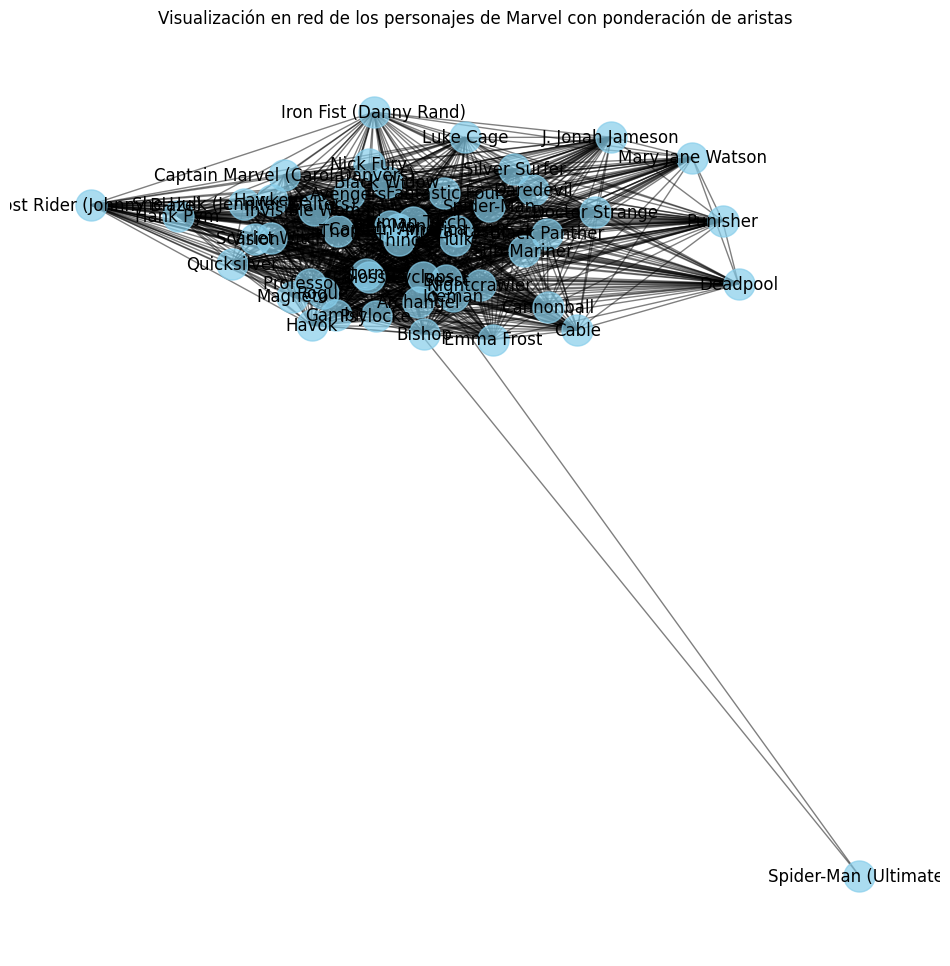

In [10]:
# We create a visualization similar to the provided format using Networkx and Matplotlib
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G)  # Positioning the nodes using the Spring layout algorithm

# We draw nodes and label them with character names
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue', alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=12)

# We draw edges and label them with weights
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='k')
edge_labels = nx.get_edge_attributes(G, 'peso')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.axis('off')  # We turn off the axis for a better visualization
plt.title('Visualización en red de los personajes de Marvel con ponderación de aristas')
plt.show()




In [11]:
# Number of nodes in the superhero groups graph
N_groups = 10

# We compute the value of p for the phase transition point.
p_phase_transition = 1 / N_groups

# We compute the value of p for the connectivity threshold
p_connectivity_threshold = np.log(N_groups) / N_groups

p_phase_transition, p_connectivity_threshold



(0.1, 0.23025850929940458)

In [12]:

# Generating random graphs using the Erdős-Rényi model for both values of p.
G_phase_transition = nx.erdos_renyi_graph(N_groups, p_phase_transition)
G_connectivity_threshold = nx.erdos_renyi_graph(N_groups, p_connectivity_threshold)

# Checking whether the graphs are connected
is_connected_phase_transition = nx.is_connected(G_phase_transition)
is_connected_connectivity_threshold = nx.is_connected(G_connectivity_threshold)

is_connected_phase_transition, is_connected_connectivity_threshold


(False, False)

## Part 2: Retweet network — 2019 Spanish general election (#28A)

In [13]:
# Path to the CSV file
file_path = '/content/drive/MyDrive/Def_PEC1_enunciado/data/RT_28A_2019.csv'

# We load the CSV file
data = pd.read_csv(file_path)

# We filter the data to keep only the retweets
retuits_data = data[data['is_retweet'] == 'VERDADERO']

# We create a directed graph
G_retuits = nx.DiGraph()

# We add the links to the graph
# Each link goes from the user who retweets (user_id) to the retweeted user (retweet_user_id)
for _, row in retuits_data.iterrows():
    user_id = row['user_id']
    retweet_user_id = row['retweet_user_id']
    # If the link already exists, we increase the weight
    if G_retuits.has_edge(user_id, retweet_user_id):
        G_retuits[user_id][retweet_user_id]['weight'] += 1
    else:
        G_retuits.add_edge(user_id, retweet_user_id, weight=1)

# We compute the number of nodes and links of the resulting graph
num_nodos = G_retuits.number_of_nodes()
num_enlaces = G_retuits.number_of_edges()

num_nodos, num_enlaces


(8165, 10226)

In [14]:
# First, we check that the weights are correctly applied in the G_retuits graph
# We will show some of the links with their weights as an example
sample_edges_with_weights = [(u, v, d['weight']) for u, v, d in G_retuits.edges(data=True)][:5]

# Computing the density of the graph
densidad = nx.density(G_retuits)

# We convert the graph to an undirected one
G_retuits_undirected = G_retuits.to_undirected()

# We check whether the undirected graph is connected
is_conexo = nx.is_connected(G_retuits_undirected)

# Analysis of the graph's connectivity
num_componentes = 0
num_nodos_componente_principal = 0
if not is_conexo:
    # We identify how many components it has
    componentes = nx.connected_components(G_retuits_undirected)
    num_componentes = nx.number_connected_components(G_retuits_undirected)

    # We compute the number of nodes of the main component (the largest one)
    componente_principal = max(componentes, key=len)
    num_nodos_componente_principal = len(componente_principal)

sample_edges_with_weights, densidad, is_conexo, num_componentes, num_nodos_componente_principal



([('x1143136944', 'x1922826367', 1),
  ('x1143136944', 'x4812690015', 1),
  ('x1143136944', 'x1070697151', 1),
  ('x1922826367', 'x121399124', 1),
  ('x1070697151', 'x1111607825262936065', 1)],
 0.00015340750379618315,
 False,
 437,
 6902)

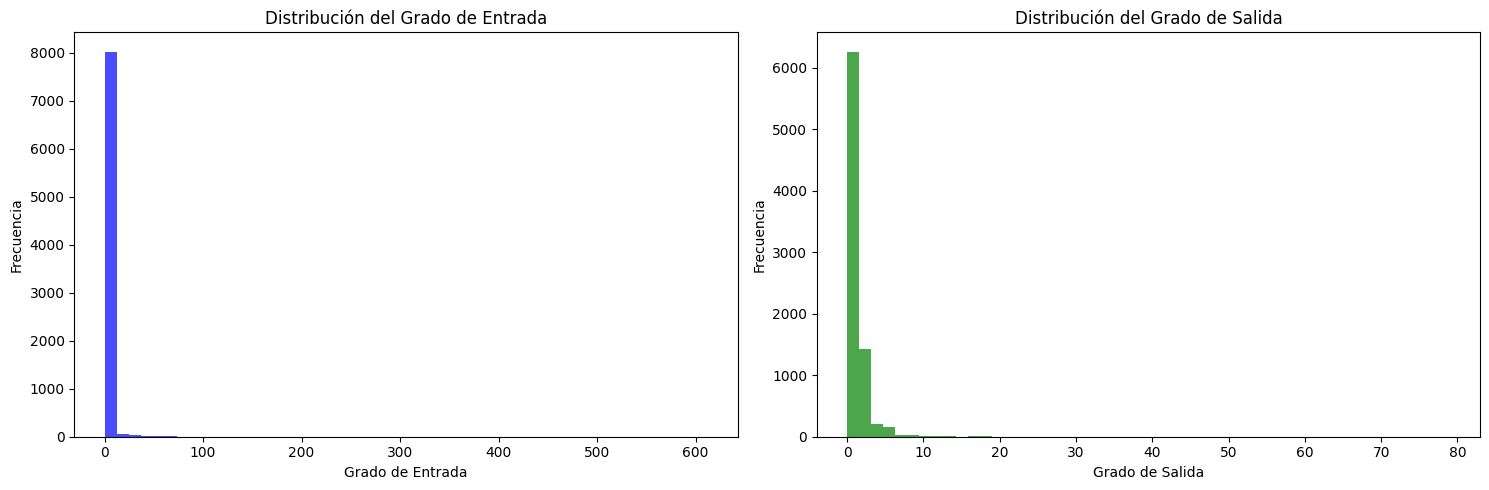

('x68740712',
 612,
 'x1143136944',
 0,
 'x1008823990683566080',
 79,
 'x4812690015',
 0)

In [15]:
# We compute the weighted in-degree and out-degree for each node
grado_entrada = dict(G_retuits.in_degree(weight='weight'))
grado_salida = dict(G_retuits.out_degree(weight='weight'))

# We identify the profiles with the maximum and minimum in-degree
max_grado_entrada = max(grado_entrada, key=grado_entrada.get)
min_grado_entrada = min(grado_entrada, key=grado_entrada.get)

# We identify the profiles with the maximum and minimum out-degree
max_grado_salida = max(grado_salida, key=grado_salida.get)
min_grado_salida = min(grado_salida, key=grado_salida.get)

# Plot of the in-degree and out-degree distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# In-degree distribution
ax1.hist(grado_entrada.values(), bins=50, color='blue', alpha=0.7)
ax1.set_title('Distribución del Grado de Entrada')
ax1.set_xlabel('Grado de Entrada')
ax1.set_ylabel('Frecuencia')

# Out-degree distribution
ax2.hist(grado_salida.values(), bins=50, color='green', alpha=0.7)
ax2.set_title('Distribución del Grado de Salida')
ax2.set_xlabel('Grado de Salida')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

max_grado_entrada, grado_entrada[max_grado_entrada], min_grado_entrada, grado_entrada[min_grado_entrada], max_grado_salida, grado_salida[max_grado_salida], min_grado_salida, grado_salida[min_grado_salida]



Both distributions exhibit a long tail, where most users have low degrees, but there is a small number of users with very high degrees. This is indicative of the power law or long-tail distributions, common in social networks.
The in-degree distribution shows that there are few heavily retweeted users (influencers), while most are retweeted only a few times or not at all.
The out-degree distribution shows a similar trend for the users who retweet, with most retweeting few users and a few retweeting many.

In [16]:
# To determine whether there have been interactions between the nodes with the highest number of retweets received,
# we will first identify the nodes with the highest in-degrees.

# We get the top N users with the most retweets received
top_n = 10  # You can adjust this number as needed
top_users_by_indegree = sorted(grado_entrada.items(), key=lambda x: x[1], reverse=True)[:top_n]

# We extract only the user IDs
top_user_ids = [user[0] for user in top_users_by_indegree]

# We check whether there have been retweets among these top users
interactions_between_top_users = []
for user_id in top_user_ids:
    for neighbor_id in G_retuits.predecessors(user_id):
        if neighbor_id in top_user_ids:
            interactions_between_top_users.append((neighbor_id, user_id))

interactions_between_top_users, top_users_by_indegree



([('x50982086', 'x68740712')],
 [('x68740712', 612),
  ('x50982086', 566),
  ('x108994652', 555),
  ('x4812690015', 362),
  ('x748256028786032640', 308),
  ('x1922826367', 278),
  ('x1070697151', 249),
  ('x780858710922891264', 234),
  ('x523386042', 216),
  ('x1097195207072890887', 209)])

Interactions among the Top Users: Among the top 10 users with the most retweets received, there has been one interaction (retweet) between the user 'x50982086' and 'x68740712'.

Users with the Highest Number of Retweets Received: The users with the highest in-degrees have a significant number of retweets received, which suggests that they are influential or popular in the network. The user with the most retweets received is 'x68740712' with 612 retweets, followed by 'x50982086' with 566 retweets, and other users with counts that are also high.

The presence of few direct interactions among the top users indicates that, although they are widely retweeted, they do not necessarily retweet each other. This may suggest that their influence is broader and is not limited to a closed circle of interaction.

Influence or popularity in the Twitter network, measured by the number of retweets received, does not necessarily imply a dense interaction network among the most influential users.

These results may reflect a dynamic in which the most popular or influential users are retweeted by a wide range of other users, extending their reach and visibility beyond a closed interaction group.

The analysis reveals a network with high-influence nodes that do not necessarily form a closed interaction group, but rather have a broader impact across the whole network.